In [1]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


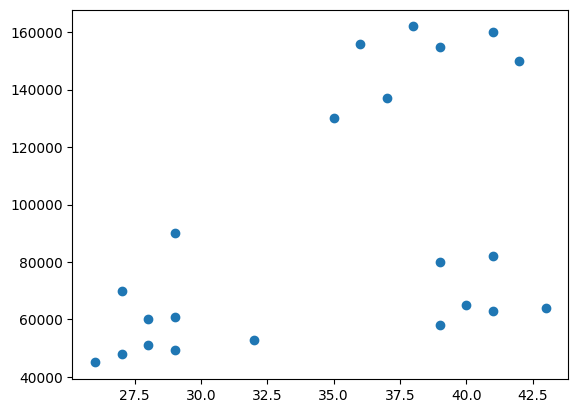

In [3]:
plt.scatter(df['Age'], df['Income($)'])
plt.show()

In [5]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3)
km.fit(df[['Age','Income($)']])

km.labels_

array([2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2],
      dtype=int32)

In [7]:
df['Cluster'] = km.labels_
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,2
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


<Axes: xlabel='Age', ylabel='Income($)'>

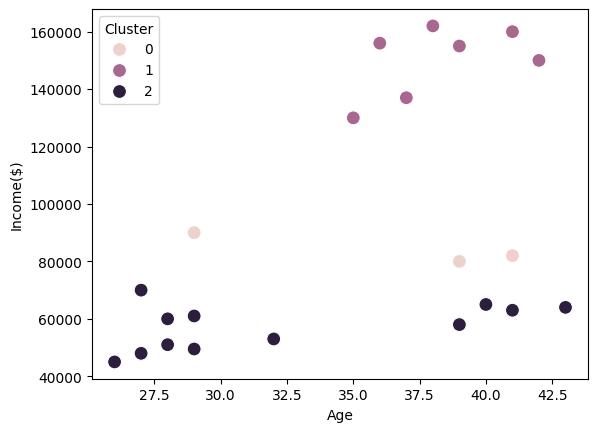

In [9]:
import seaborn as sns

sns.scatterplot(df,x = 'Age',y='Income($)',s = 100, hue='Cluster')

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = pd.DataFrame(columns=['Age','Income($)'])

df_scaled[['Age','Income($)']]  = scaler.fit_transform(df[['Age','Income($)']])
df_scaled.head()

,Age,Income($)
0,0.058824,0.213675
1,0.176471,0.384615
2,0.176471,0.136752
3,0.117647,0.128205
4,0.941176,0.897436


In [16]:
km = KMeans(n_clusters=3)
km.fit(df_scaled[['Age','Income($)']])

df_scaled['Cluster'] = km.labels_
df_scaled.head()

,Age,Income($),Cluster
0,0.058824,0.213675,1
1,0.176471,0.384615,1
2,0.176471,0.136752,1
3,0.117647,0.128205,1
4,0.941176,0.897436,2


In [19]:
centroids = km.cluster_centers_
centroids

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

<Axes: xlabel='Age', ylabel='Income($)'>

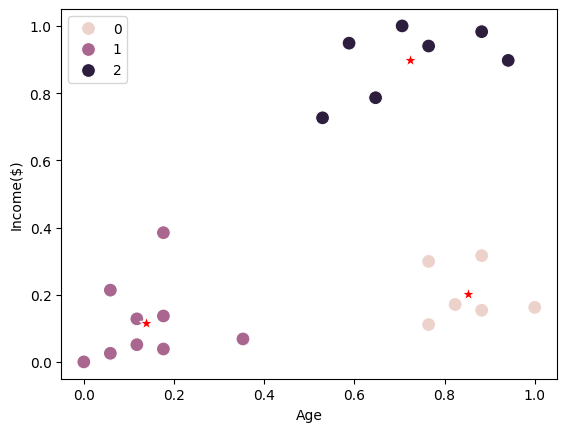

In [23]:
sns.scatterplot(df_scaled,x='Age',y='Income($)',s=100,hue='Cluster')
sns.scatterplot(x = centroids[:,0],y=centroids[:,1],s=100,color = 'red',marker='*')

In [24]:
sse = []

k_rng = range(1,10)

for k in k_rng:
    km = KMeans(n_clusters=k,n_init='auto')
    km.fit(df_scaled[['Age',"Income($)"]])
    sse.append(km.inertia_)

sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.34910470944195654,
 0.2965427603621494,
 0.24387536901677193,
 0.23403921890912846,
 0.1591933318857875,
 0.11570653846701522]

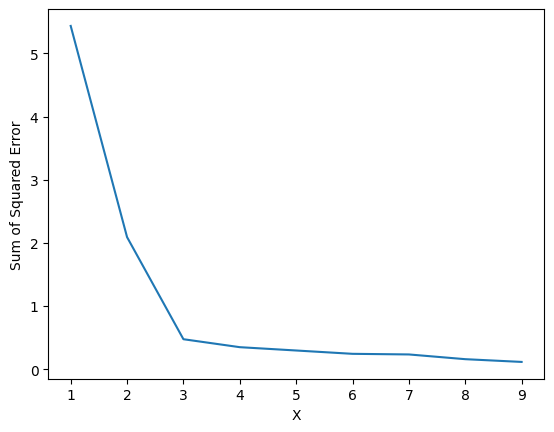

In [25]:
plt.xlabel('X')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng,sse)
plt.show()